In [ ]:
import pandas as pd

# Load CSV file into a DataFrame
df = pd.read_csv('/content/drive/MyDrive/df_merged_cleaned.csv')

# Display the first 5 rows
print(df.head())
df.shape

   SK_ID_CURR  TARGET  NAME_CONTRACT_TYPE  FLAG_OWN_CAR  FLAG_OWN_REALTY  \
0      100002       1                   0             0                1   
1      100003       0                   0             0                0   
2      100004       0                   1             1                1   
3      100006       0                   0             0                1   
4      100007       0                   0             0                1   

   CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0             0          202500.0    406597.5      24700.5         351000.0   
1             0          270000.0   1293502.5      35698.5        1129500.0   
2             0           67500.0    135000.0       6750.0         135000.0   
3             0          135000.0    312682.5      29686.5         297000.0   
4             0          121500.0    513000.0      21865.5         513000.0   

   ...  SK_DPD_DEF_max  SK_DPD_DEF_min  SK_DPD_DEF_count  \
0  ...  

(307511, 657)

In [ ]:
# Check data types
print(df.dtypes)

# Check for missing values
print(df.isnull().sum())


SK_ID_CURR                              int64
TARGET                                  int64
NAME_CONTRACT_TYPE                      int64
FLAG_OWN_CAR                            int64
FLAG_OWN_REALTY                         int64
                                       ...   
NAME_CONTRACT_STATUS_Completed_y      float64
NAME_CONTRACT_STATUS_Demand_y         float64
NAME_CONTRACT_STATUS_Refused_y        float64
NAME_CONTRACT_STATUS_Sent proposal    float64
NAME_CONTRACT_STATUS_Signed_y         float64
Length: 657, dtype: object
SK_ID_CURR                                 0
TARGET                                     0
NAME_CONTRACT_TYPE                         0
FLAG_OWN_CAR                               0
FLAG_OWN_REALTY                            0
                                       ...  
NAME_CONTRACT_STATUS_Completed_y      220606
NAME_CONTRACT_STATUS_Demand_y         220606
NAME_CONTRACT_STATUS_Refused_y        220606
NAME_CONTRACT_STATUS_Sent proposal    220606
NAME_CONTRACT_STA

In [ ]:
# Check for new missing values after the join
print("Missing values after join:")
print(df.isnull().sum().sort_values(ascending=False))

Missing values after join:
SK_DPD_sum                         220606
NAME_CONTRACT_STATUS_Signed_y      220606
SK_DPD_mean                        220606
CNT_INSTALMENT_MATURE_CUM_count    220606
CNT_INSTALMENT_MATURE_CUM_min      220606
                                    ...  
LIVE_REGION_NOT_WORK_REGION             0
REG_CITY_NOT_LIVE_CITY                  0
REG_CITY_NOT_WORK_CITY                  0
LIVE_CITY_NOT_WORK_CITY                 0
EXT_SOURCE_1                            0
Length: 657, dtype: int64


In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

In [ ]:
print(f"Categorical columns: {categorical_cols}")
print(f"Numeric columns: {len(numeric_cols)} columns")

Categorical columns: []
Numeric columns: 537 columns


In [ ]:
print("Missing values check:")
print(df.isnull().sum().sum())


Missing values check:
30864083


In [ ]:
print("Data types:")
print(df.dtypes.value_counts())


Data types:
float64    491
bool       120
int64       46
Name: count, dtype: int64


In [ ]:
# Check missing values per column
missing_per_column = df.isnull().sum().sort_values(ascending=False)
missing_percentage = (missing_per_column / len(df)) * 100

print("Top 20 columns with most missing values:")
for col in missing_per_column.head(20).index:
    count = missing_per_column[col]
    percent = missing_percentage[col]
    print(f"{col}: {count:,} missing ({percent:.1f}%)")


Top 20 columns with most missing values:
SK_DPD_sum: 220,606 missing (71.7%)
NAME_CONTRACT_STATUS_Signed_y: 220,606 missing (71.7%)
SK_DPD_mean: 220,606 missing (71.7%)
CNT_INSTALMENT_MATURE_CUM_count: 220,606 missing (71.7%)
CNT_INSTALMENT_MATURE_CUM_min: 220,606 missing (71.7%)
CNT_INSTALMENT_MATURE_CUM_max: 220,606 missing (71.7%)
CNT_INSTALMENT_MATURE_CUM_sum: 220,606 missing (71.7%)
CNT_INSTALMENT_MATURE_CUM_mean: 220,606 missing (71.7%)
CNT_DRAWINGS_POS_CURRENT_count: 220,606 missing (71.7%)
CNT_DRAWINGS_POS_CURRENT_min: 220,606 missing (71.7%)
AMT_RECEIVABLE_PRINCIPAL_mean: 220,606 missing (71.7%)
AMT_RECEIVABLE_PRINCIPAL_count: 220,606 missing (71.7%)
AMT_RECEIVABLE_PRINCIPAL_sum: 220,606 missing (71.7%)
AMT_RECEIVABLE_PRINCIPAL_max: 220,606 missing (71.7%)
AMT_RECEIVABLE_PRINCIPAL_min: 220,606 missing (71.7%)
AMT_RECIVABLE_sum: 220,606 missing (71.7%)
AMT_RECIVABLE_mean: 220,606 missing (71.7%)
AMT_RECIVABLE_max: 220,606 missing (71.7%)
AMT_RECIVABLE_min: 220,606 missing (71.7

In [ ]:
# Drop columns with more than 70% missing data
threshold = 0.7
cols_to_drop = missing_percentage[missing_percentage > threshold * 100].index
print(f"Columns to drop (>{threshold*100}% missing): {len(cols_to_drop)}")
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Shape after dropping high-missing columns: {df_cleaned.shape}")


Columns to drop (>70.0% missing): 107
Shape after dropping high-missing columns: (307511, 550)


In [ ]:
# For boolean columns
for col in df_cleaned.select_dtypes(include='bool').columns:
    if df_cleaned[col].isnull().sum() > 0:
        # Use mode
        mode_val = df_cleaned[col].mode().iloc[0] if not df_cleaned[col].mode().empty else False
        df_cleaned[col] = df_cleaned[col].fillna(mode_val)

# For numeric columns - you can choose between mean/median
for col in df_cleaned.select_dtypes(include=['int64', 'float64']).columns:
    if df_cleaned[col].isnull().sum() > 0:
        # Use median for robustness against outliers
        median_val = df_cleaned[col].median()
        df_cleaned[col] = df_cleaned[col].fillna(median_val)


In [ ]:
print("Missing values after imputation:", df_cleaned.isnull().sum().sum())


Missing values after imputation: 0


In [ ]:
# Final check
print("Final dataset shape:", df_cleaned.shape)
print("Final missing values:", df_cleaned.isnull().sum().sum())
print("Data types:", df_cleaned.dtypes.value_counts())


Final dataset shape: (307511, 550)
Final missing values: 0
Data types: float64    384
bool       120
int64       46
Name: count, dtype: int64


In [ ]:
# Convert boolean to int (0/1) for better compatibility
bool_cols = df_cleaned.select_dtypes(include='bool').columns
df_cleaned[bool_cols] = df_cleaned[bool_cols].astype(int)

print("Final data types after boolean conversion:")
print(df_cleaned.dtypes.value_counts())


Final data types after boolean conversion:
float64    384
int64      166
Name: count, dtype: int64


In [ ]:
# Save your cleaned dataset to CSV
df.to_csv('/content/drive/MyDrive/home-credit-default-risk/cleaned_dataset.csv', index=False)
print("Dataset saved successfully!")
print(f"Saved dataset shape: {df_cleaned.shape}")


Dataset saved successfully!
Saved dataset shape: (307511, 550)


After this we used this dataset to create df_final_strategic.csv in df_final_strategic.ipynb


In [ ]:
import pandas as pd

# Load CSV file into a DataFrame
df_cleaned = pd.read_csv('/content/drive/MyDrive/home-credit-default-risk/df_final_strategic.csv')  # Replace with your actual file path

# Display the first 5 rows
print(df_cleaned.head())
df_cleaned.shape

   SK_ID_CURR  TARGET  NAME_CONTRACT_TYPE  FLAG_OWN_CAR  FLAG_OWN_REALTY  \
0      100002       1                   0             0                1   
1      100003       0                   0             0                0   
2      100004       0                   1             1                1   
3      100006       0                   0             0                1   
4      100007       0                   0             0                1   

   CNT_CHILDREN  AMT_INCOME_TOTAL  AMT_CREDIT  AMT_ANNUITY  AMT_GOODS_PRICE  \
0             0          202500.0    406597.5      24700.5         351000.0   
1             0          270000.0   1293502.5      35698.5        1129500.0   
2             0           67500.0    135000.0       6750.0         135000.0   
3             0          135000.0    312682.5      29686.5         297000.0   
4             0          121500.0    513000.0      21865.5         513000.0   

   ...  POS_SK_DPD_DEF_SUM  NAME_CONTRACT_STATUS_Active_x  \
0  ... 

(307511, 364)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

X = df_cleaned.drop('TARGET', axis=1)
y = df_cleaned['TARGET']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest for feature importance...")
rf.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print("Training completed!")


Features shape: (307511, 363)
Target shape: (307511,)
Training Random Forest for feature importance...
Training completed!


<ipython-input-3-1630655910>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')


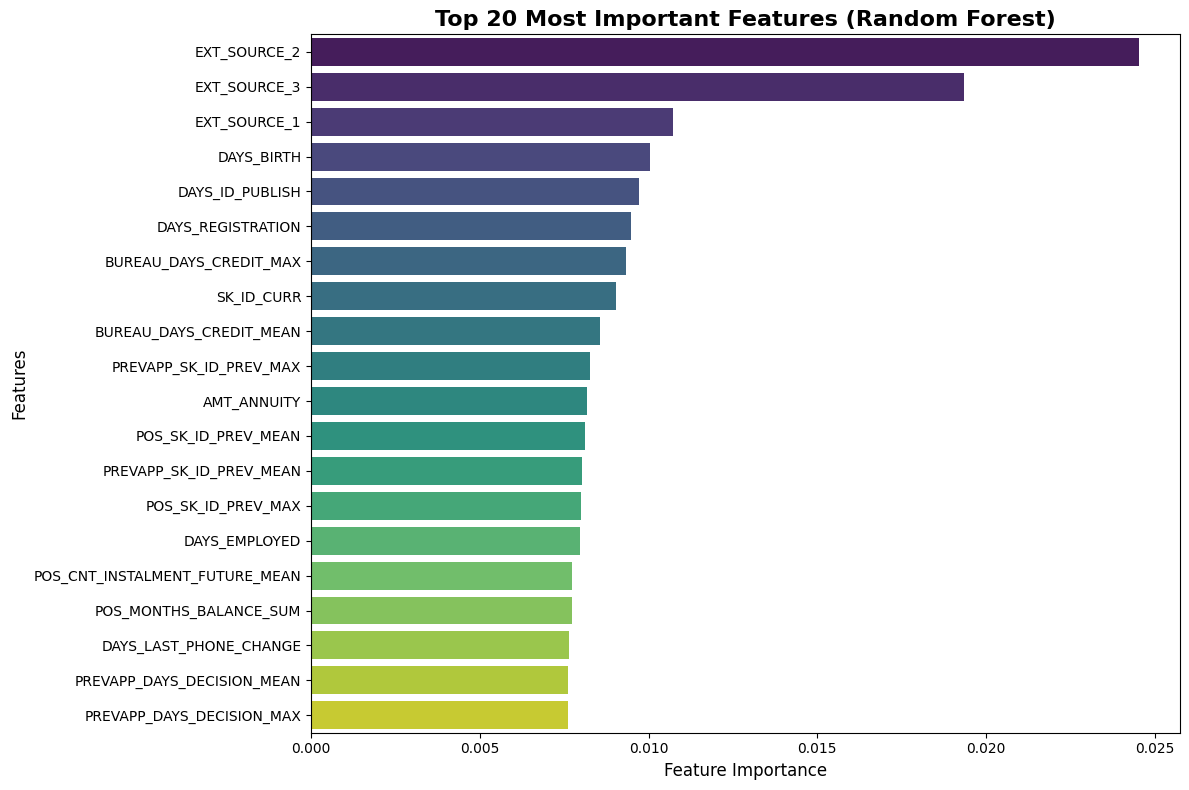


Top 20 Most Important Features:
 1. EXT_SOURCE_2                             0.0245
 2. EXT_SOURCE_3                             0.0193
 3. EXT_SOURCE_1                             0.0107
 4. DAYS_BIRTH                               0.0100
 5. DAYS_ID_PUBLISH                          0.0097
 6. DAYS_REGISTRATION                        0.0095
 7. BUREAU_DAYS_CREDIT_MAX                   0.0093
 8. SK_ID_CURR                               0.0090
 9. BUREAU_DAYS_CREDIT_MEAN                  0.0086
10. PREVAPP_SK_ID_PREV_MAX                   0.0083
11. AMT_ANNUITY                              0.0082
12. POS_SK_ID_PREV_MEAN                      0.0081
13. PREVAPP_SK_ID_PREV_MEAN                  0.0080
14. POS_SK_ID_PREV_MAX                       0.0080
15. DAYS_EMPLOYED                            0.0080
16. POS_CNT_INSTALMENT_FUTURE_MEAN           0.0077
17. POS_MONTHS_BALANCE_SUM                   0.0077
18. DAYS_LAST_PHONE_CHANGE                   0.0076
19. PREVAPP_DAYS_DECISION_MEAN 

In [ ]:

plt.figure(figsize=(12, 8))
top_features = feature_importance.head(20)

sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Features:")
print("="*50)
for i, (idx, row) in enumerate(top_features.iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<40} {row['importance']:.4f}")


<ipython-input-4-4153336299>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')


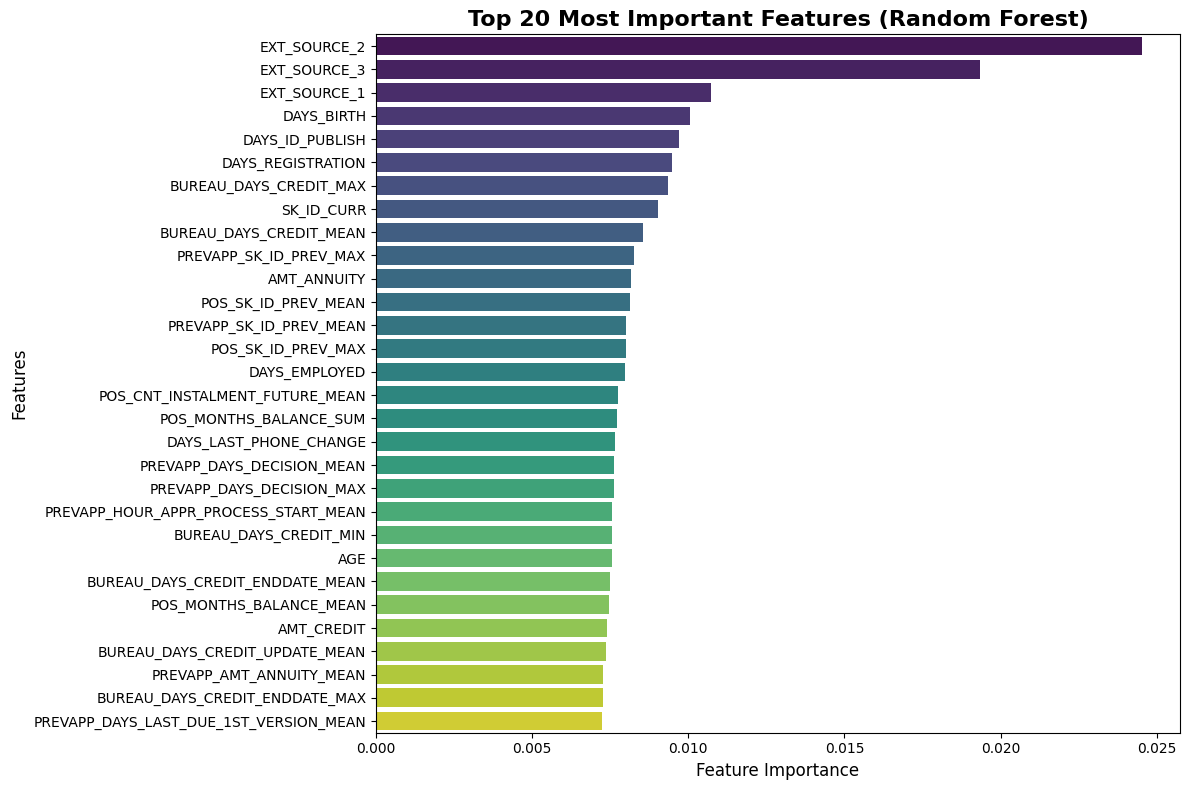


Top 30 Most Important Features:
 1. EXT_SOURCE_2                             0.0245
 2. EXT_SOURCE_3                             0.0193
 3. EXT_SOURCE_1                             0.0107
 4. DAYS_BIRTH                               0.0100
 5. DAYS_ID_PUBLISH                          0.0097
 6. DAYS_REGISTRATION                        0.0095
 7. BUREAU_DAYS_CREDIT_MAX                   0.0093
 8. SK_ID_CURR                               0.0090
 9. BUREAU_DAYS_CREDIT_MEAN                  0.0086
10. PREVAPP_SK_ID_PREV_MAX                   0.0083
11. AMT_ANNUITY                              0.0082
12. POS_SK_ID_PREV_MEAN                      0.0081
13. PREVAPP_SK_ID_PREV_MEAN                  0.0080
14. POS_SK_ID_PREV_MAX                       0.0080
15. DAYS_EMPLOYED                            0.0080
16. POS_CNT_INSTALMENT_FUTURE_MEAN           0.0077
17. POS_MONTHS_BALANCE_SUM                   0.0077
18. DAYS_LAST_PHONE_CHANGE                   0.0076
19. PREVAPP_DAYS_DECISION_MEAN 

In [ ]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(30)

sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 30 Most Important Features:")
print("="*50)
for i, (idx, row) in enumerate(top_features.iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<40} {row['importance']:.4f}")


<ipython-input-5-726849988>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')


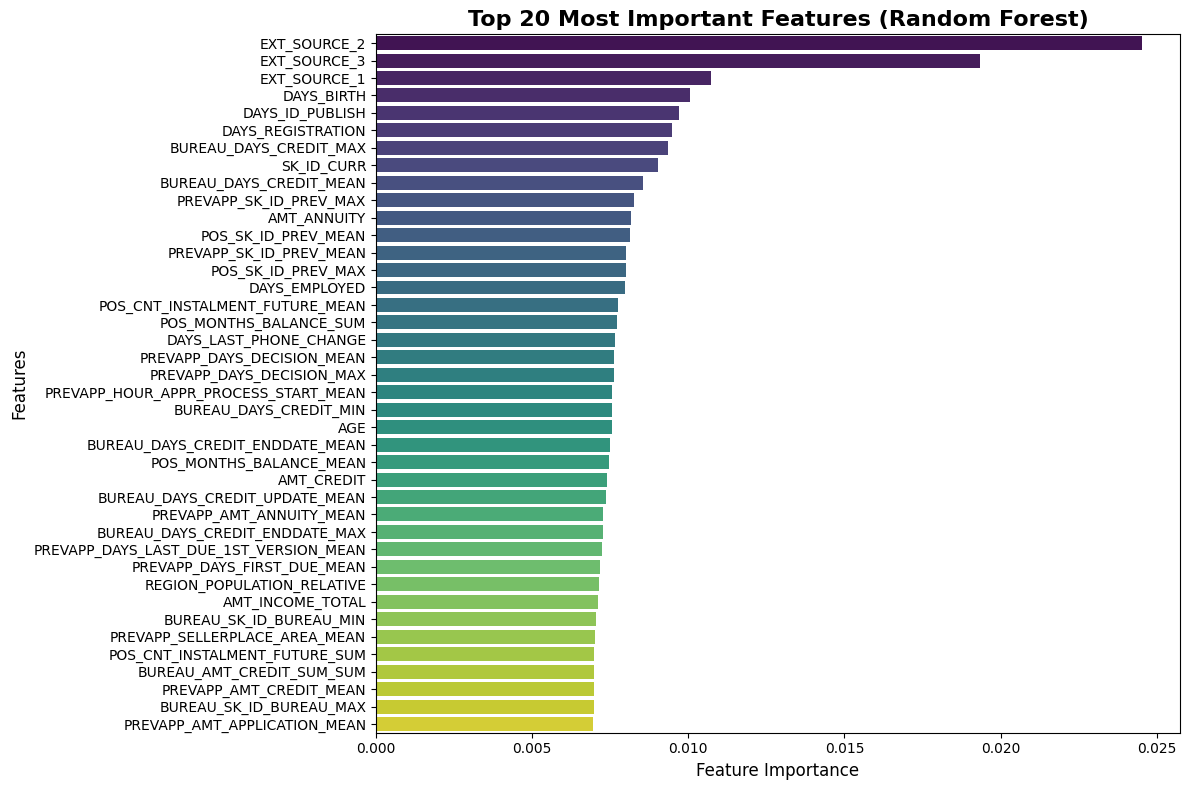


Top 40 Most Important Features:
 1. EXT_SOURCE_2                             0.0245
 2. EXT_SOURCE_3                             0.0193
 3. EXT_SOURCE_1                             0.0107
 4. DAYS_BIRTH                               0.0100
 5. DAYS_ID_PUBLISH                          0.0097
 6. DAYS_REGISTRATION                        0.0095
 7. BUREAU_DAYS_CREDIT_MAX                   0.0093
 8. SK_ID_CURR                               0.0090
 9. BUREAU_DAYS_CREDIT_MEAN                  0.0086
10. PREVAPP_SK_ID_PREV_MAX                   0.0083
11. AMT_ANNUITY                              0.0082
12. POS_SK_ID_PREV_MEAN                      0.0081
13. PREVAPP_SK_ID_PREV_MEAN                  0.0080
14. POS_SK_ID_PREV_MAX                       0.0080
15. DAYS_EMPLOYED                            0.0080
16. POS_CNT_INSTALMENT_FUTURE_MEAN           0.0077
17. POS_MONTHS_BALANCE_SUM                   0.0077
18. DAYS_LAST_PHONE_CHANGE                   0.0076
19. PREVAPP_DAYS_DECISION_MEAN 

In [ ]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(40)

sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 40 Most Important Features:")
print("="*50)
for i, (idx, row) in enumerate(top_features.iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<40} {row['importance']:.4f}")


<ipython-input-6-3814755389>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')


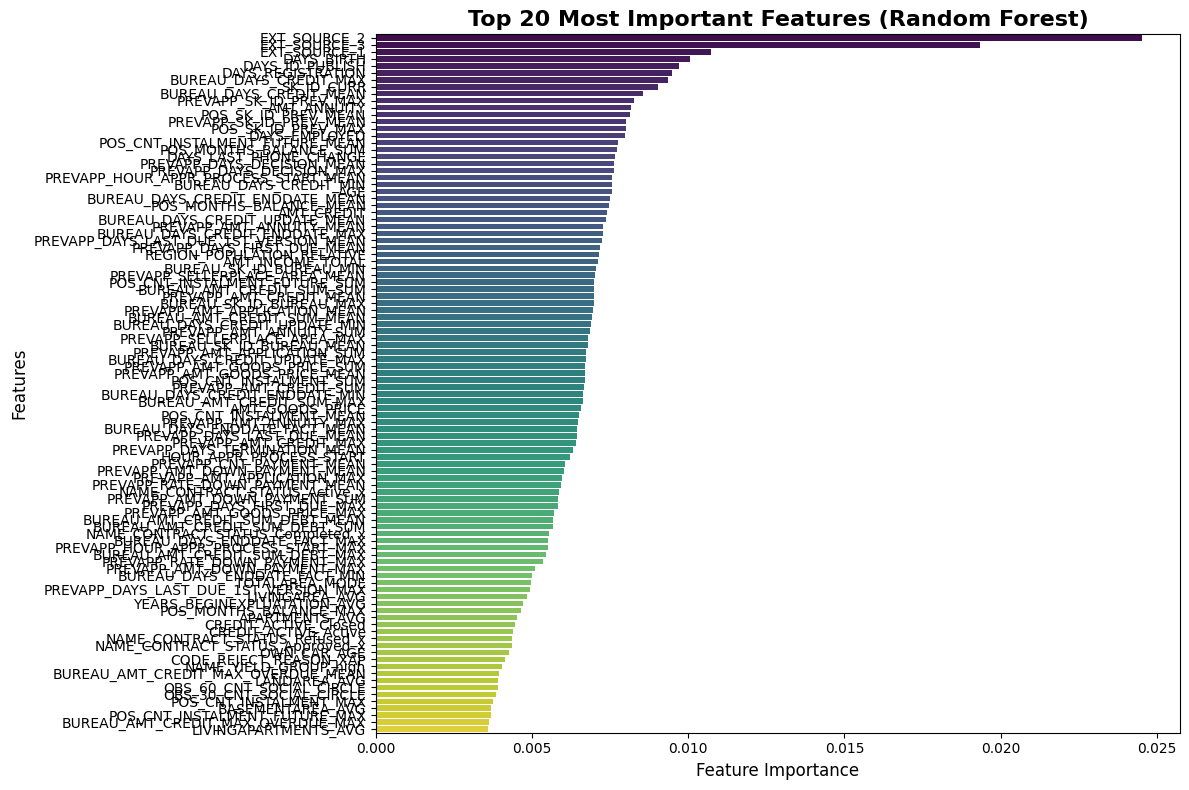


Top 20 Most Important Features:
 1. EXT_SOURCE_2                             0.0245
 2. EXT_SOURCE_3                             0.0193
 3. EXT_SOURCE_1                             0.0107
 4. DAYS_BIRTH                               0.0100
 5. DAYS_ID_PUBLISH                          0.0097
 6. DAYS_REGISTRATION                        0.0095
 7. BUREAU_DAYS_CREDIT_MAX                   0.0093
 8. SK_ID_CURR                               0.0090
 9. BUREAU_DAYS_CREDIT_MEAN                  0.0086
10. PREVAPP_SK_ID_PREV_MAX                   0.0083
11. AMT_ANNUITY                              0.0082
12. POS_SK_ID_PREV_MEAN                      0.0081
13. PREVAPP_SK_ID_PREV_MEAN                  0.0080
14. POS_SK_ID_PREV_MAX                       0.0080
15. DAYS_EMPLOYED                            0.0080
16. POS_CNT_INSTALMENT_FUTURE_MEAN           0.0077
17. POS_MONTHS_BALANCE_SUM                   0.0077
18. DAYS_LAST_PHONE_CHANGE                   0.0076
19. PREVAPP_DAYS_DECISION_MEAN 

In [ ]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(100)

sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 20 Most Important Features:")
print("="*50)
for i, (idx, row) in enumerate(top_features.iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<40} {row['importance']:.4f}")


<ipython-input-7-3996148651>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')


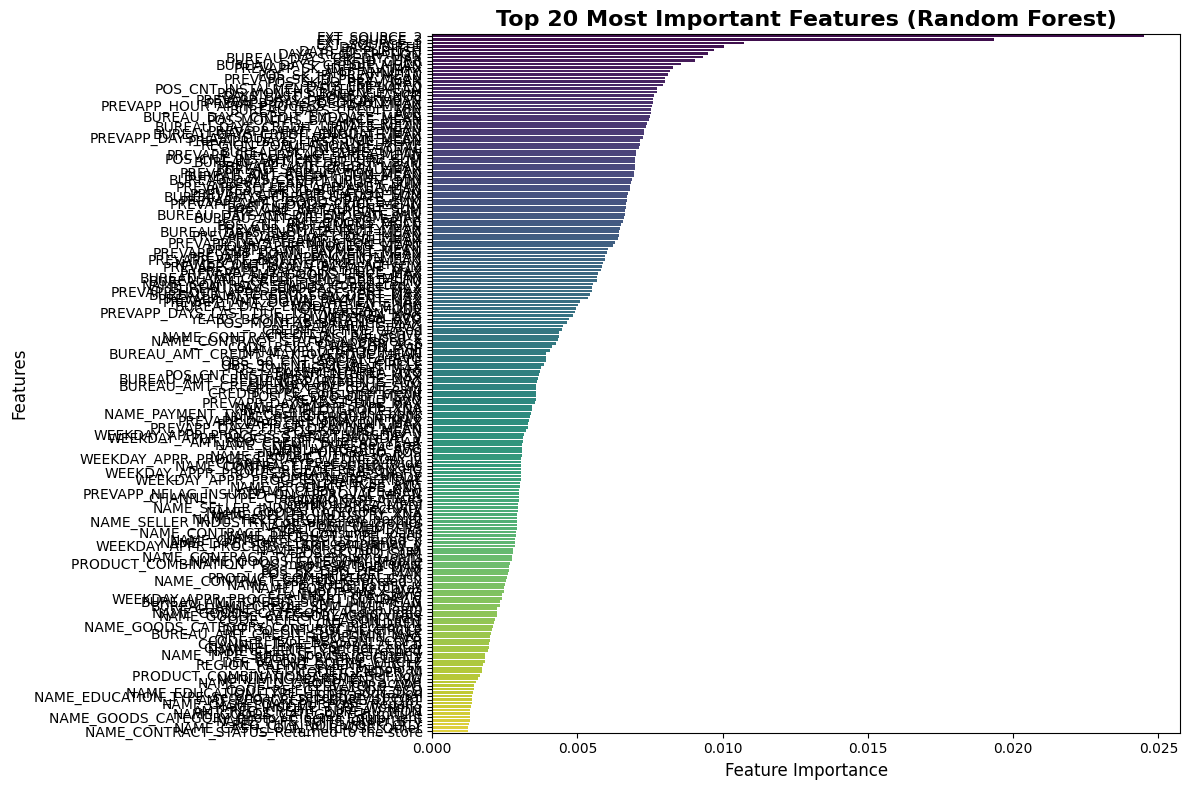


Top 200 Most Important Features:
 1. EXT_SOURCE_2                             0.0245
 2. EXT_SOURCE_3                             0.0193
 3. EXT_SOURCE_1                             0.0107
 4. DAYS_BIRTH                               0.0100
 5. DAYS_ID_PUBLISH                          0.0097
 6. DAYS_REGISTRATION                        0.0095
 7. BUREAU_DAYS_CREDIT_MAX                   0.0093
 8. SK_ID_CURR                               0.0090
 9. BUREAU_DAYS_CREDIT_MEAN                  0.0086
10. PREVAPP_SK_ID_PREV_MAX                   0.0083
11. AMT_ANNUITY                              0.0082
12. POS_SK_ID_PREV_MEAN                      0.0081
13. PREVAPP_SK_ID_PREV_MEAN                  0.0080
14. POS_SK_ID_PREV_MAX                       0.0080
15. DAYS_EMPLOYED                            0.0080
16. POS_CNT_INSTALMENT_FUTURE_MEAN           0.0077
17. POS_MONTHS_BALANCE_SUM                   0.0077
18. DAYS_LAST_PHONE_CHANGE                   0.0076
19. PREVAPP_DAYS_DECISION_MEAN

In [ ]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(200)

sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 200 Most Important Features:")
print("="*50)
for i, (idx, row) in enumerate(top_features.iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<40} {row['importance']:.4f}")


<ipython-input-8-783812256>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')


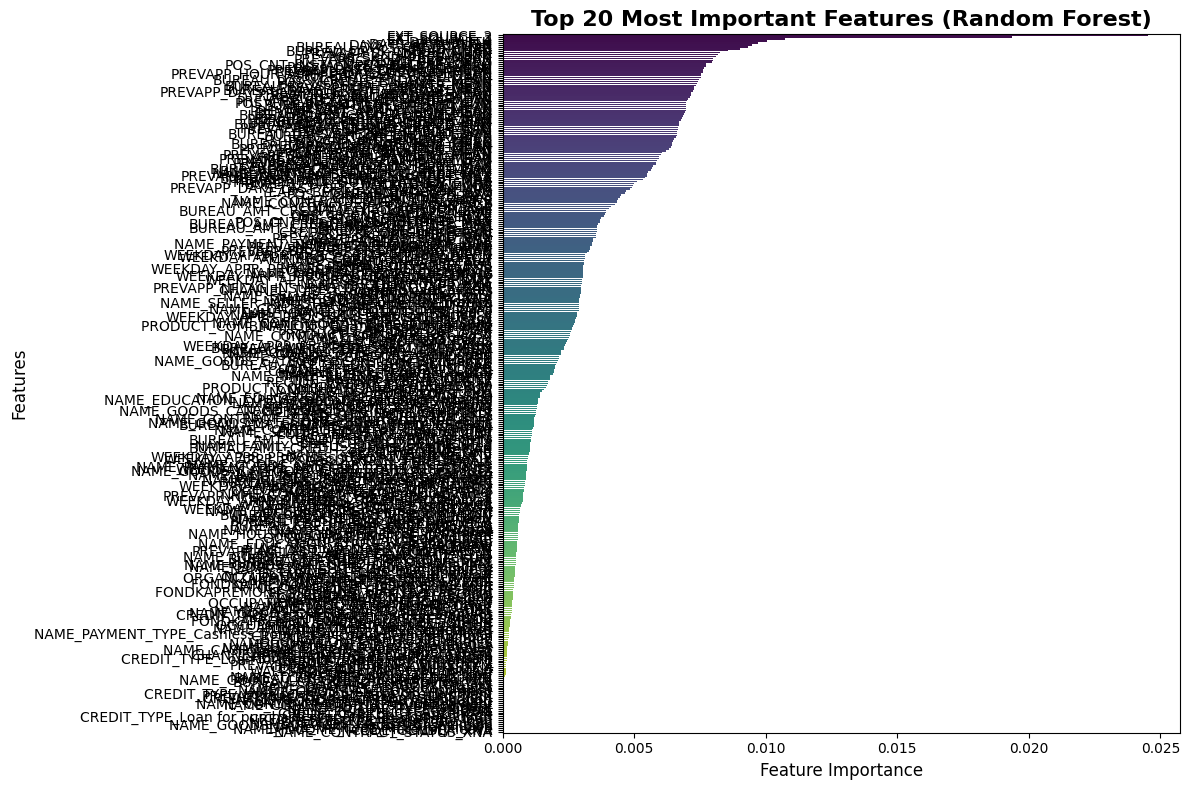


Top 550 Most Important Features:
 1. EXT_SOURCE_2                             0.0245
 2. EXT_SOURCE_3                             0.0193
 3. EXT_SOURCE_1                             0.0107
 4. DAYS_BIRTH                               0.0100
 5. DAYS_ID_PUBLISH                          0.0097
 6. DAYS_REGISTRATION                        0.0095
 7. BUREAU_DAYS_CREDIT_MAX                   0.0093
 8. SK_ID_CURR                               0.0090
 9. BUREAU_DAYS_CREDIT_MEAN                  0.0086
10. PREVAPP_SK_ID_PREV_MAX                   0.0083
11. AMT_ANNUITY                              0.0082
12. POS_SK_ID_PREV_MEAN                      0.0081
13. PREVAPP_SK_ID_PREV_MEAN                  0.0080
14. POS_SK_ID_PREV_MAX                       0.0080
15. DAYS_EMPLOYED                            0.0080
16. POS_CNT_INSTALMENT_FUTURE_MEAN           0.0077
17. POS_MONTHS_BALANCE_SUM                   0.0077
18. DAYS_LAST_PHONE_CHANGE                   0.0076
19. PREVAPP_DAYS_DECISION_MEAN

In [ ]:
plt.figure(figsize=(12, 8))
top_features = feature_importance.head(364)

sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title('Top 20 Most Important Features (Random Forest)', fontsize=16, fontweight='bold')
plt.xlabel('Feature Importance', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 550 Most Important Features:")
print("="*50)
for i, (idx, row) in enumerate(top_features.iterrows(), 1):
    print(f"{i:2d}. {row['feature']:<40} {row['importance']:.4f}")


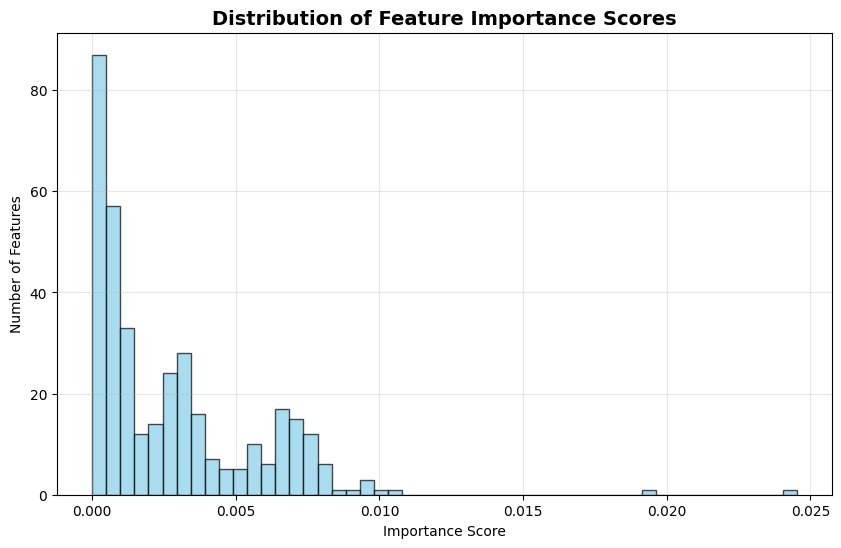


Top 10 features account for 0.119 of total importance
Top 20 features account for 0.198 of total importance
Top 50 features account for 0.410 of total importance


In [ ]:
# Feature importance distribution
plt.figure(figsize=(10, 6))
plt.hist(feature_importance['importance'], bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('Distribution of Feature Importance Scores', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Number of Features')
plt.grid(True, alpha=0.3)
plt.show()

# Show cumulative importance
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()
print(f"\nTop 10 features account for {feature_importance.head(10)['cumulative_importance'].iloc[-1]:.3f} of total importance")
print(f"Top 20 features account for {feature_importance.head(20)['cumulative_importance'].iloc[-1]:.3f} of total importance")
print(f"Top 50 features account for {feature_importance.head(50)['cumulative_importance'].iloc[-1]:.3f} of total importance")


In [ ]:
# Show cumulative importance
feature_importance['cumulative_importance'] = feature_importance['importance'].cumsum()
print(f"\nTop 100 features account for {feature_importance.head(100)['cumulative_importance'].iloc[-1]:.3f} of total importance")
print(f"Top 175 features account for {feature_importance.head(175)['cumulative_importance'].iloc[-1]:.3f} of total importance")
print(f"Top 300 features account for {feature_importance.head(300)['cumulative_importance'].iloc[-1]:.3f} of total importance")



Top 100 features account for 0.670 of total importance
Top 175 features account for 0.883 of total importance
Top 300 features account for 0.992 of total importance
